<a href="https://colab.research.google.com/github/liskraatz/Titanic-Project/blob/LisaModelUpdate/titanic_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
plt.style.use('dark_background')
%matplotlib inline
warnings.filterwarnings('ignore')

train = pd.read_csv('titanic-data-train.csv')
test = pd.read_csv('titanic-data-test.csv')

# To know number of colums and rows
train.shape
# (891, 12)

print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch              Ticket      Fare            Cabin Embarked
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0           A/5 21171    7.2500              NaN        S
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0            PC 17599   71.2833              C85        C
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    STON/O2. 3101282    7.9250              NaN        S
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0              113803   53.1000       

In [ ]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


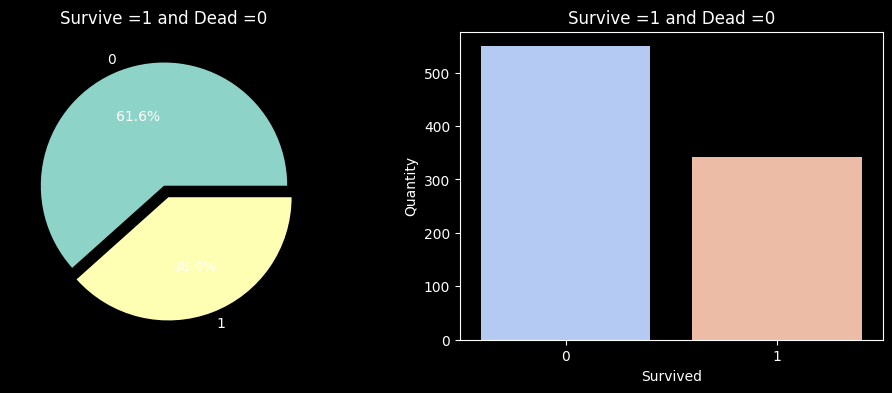

In [ ]:
f, ax=plt.subplots(1,2, figsize=(12,4))
train['Survived'].value_counts().plot.pie(explode=[0,0.1], autopct='%1.1f%%', ax=ax[0], shadow=False)
ax[0].set_title('Survive =1 and Dead =0')
ax[0].set_ylabel('')

sns.countplot(x='Survived', data=train, ax=ax[1], palette='coolwarm')
ax[1].set_title('Survive =1 and Dead =0')
ax[1].set_ylabel('Quantity')
plt.show()

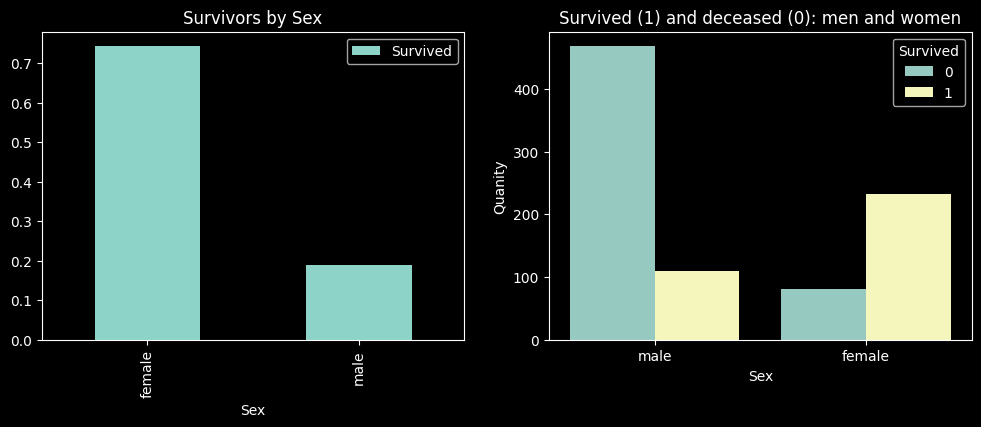

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(12,4))

#count 1b
train[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survivors by Sex')

#count 2
sns.countplot(x='Sex', hue='Survived', data=train, ax=ax[1])
ax[1].set_ylabel('Quanity')
ax[1].set_title('Survived (1) and deceased (0): men and women')
plt.show()

In [ ]:
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)
train = train.drop(['Ticket'], axis=1)
test = test.drop(['Ticket'], axis=1)
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S
4              5         0       3                                                            Allen, Mr. William Henry    male  35.00      0      0    8.0500        

In [ ]:
train = train.fillna({"Embarked": "S"})
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S
4              5         0       3                                                            Allen, Mr. William Henry    male  35.00      0      0    8.0500        

In [ ]:
# sort the ages into logical categories
train["Age"] = train["Age"].fillna(-0.5)
test["Age"] = test["Age"].fillna(-0.5)
bins = [-1, 0, 4, 12, 15, 19, 39, 49, np.inf]
labels = ['Unknown', 'Infant', 'Child', 'Young','Teenager',
          'Adult', 'Middle Aged', 'Senior']
train['AgeGroup'] = pd.cut(train["Age"], bins, labels=labels)
test['AgeGroup'] = pd.cut(test["Age"], bins, labels=labels)
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked     AgeGroup
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S        Adult
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C        Adult
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S        Adult
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S        Adult
4              5         0       3                                                            Allen,

In [ ]:
#create a combined group of both datasets
combine = [train, test]

#extract a title for each name in the
#train and test datasets
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

#pd.crosstab(train['Title'], train['Sex'])

#replace various titles with more common names
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
                                                'Don', 'Dr', 'Major',
                                                'Rev', 'Jonkheer', 'Dona',
                                              'Rare'])

    dataset['Title'] = dataset['Title'].replace(
        ['Countess', 'Lady', 'Sir'], 'Royal')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

#train[['Title', 'Survived]].groupby(['Title'], as_index=False).mean()

#map each of the title gourps to a numerical value
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
                 "Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

In [ ]:
pd.crosstab(train['Title'], train['Sex'])

Sex,female,male
Title,,
1,2,531
2,185,2
3,126,3
4,0,40
5,1,1


In [ ]:
train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,1,0.161351
1,2,0.700535
2,3,0.775194
3,4,0.575000
4,5,1.000000


In [ ]:
age_title_mapping = {1: "Adult", 2:"Teenager", 3: "Adult", 4: "Child", # Master title was used for young boys
        5: "Middle Aged",6:  "Adult"}
for x in range(len(train["AgeGroup"])):
    if train["AgeGroup"][x] == "Unknown":
        train["AgeGroup"][x] = age_title_mapping[train["Title"][x]]

for x in range(len(test["AgeGroup"])):
    if test["AgeGroup"][x] == "Unknown":
        test["AgeGroup"][x] = age_title_mapping[test["Title"][x]]

In [ ]:
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked     AgeGroup  Title
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S        Adult      1
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C        Adult      3
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S        Adult      2
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S        Adult      3
4              5         0       3                               

In [ ]:
# map each Age value to a numerical value
age_mapping = {"Infant": 1, "Child": 2, "Young": 3,
        "Teenager": 4, "Adult": 5, "Middle Aged": 6,
        "Senior": 7, "Unknown": 0}
train["AgeGroup"] = train["AgeGroup"].map(age_mapping)
test["AgeGroup"] = test["AgeGroup"].map(age_mapping)

train.head()

# drop the age
train = train.drop(['AgeGroup'], axis=1)
test = test.drop(['AgeGroup'], axis=1)

In [ ]:
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked  Title
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S      1
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C      3
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S      2
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S      3
4              5         0       3                                                            Allen, Mr. William Henry    male  35

In [ ]:
train = train.drop(['Name'], axis=1)
test = test.drop(['Name'], axis=1)

In [ ]:
sex_mapping = {"male": 0, "female": 1}
train['Sex'] = train['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

embarked_mapping = {"S": 1, "C": 2, "Q": 3}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)

In [ ]:
print(train.to_string())

     PassengerId  Survived  Pclass  Sex    Age  SibSp  Parch      Fare  Embarked  Title
0              1         0       3    0  22.00      1      0    7.2500         1      1
1              2         1       1    1  38.00      1      0   71.2833         2      3
2              3         1       3    1  26.00      0      0    7.9250         1      2
3              4         1       1    1  35.00      1      0   53.1000         1      3
4              5         0       3    0  35.00      0      0    8.0500         1      1
5              6         0       3    0  -0.50      0      0    8.4583         3      1
6              7         0       1    0  54.00      0      0   51.8625         1      1
7              8         0       3    0   2.00      3      1   21.0750         1      4
8              9         1       3    1  27.00      0      2   11.1333         1      3
9             10         1       2    1  14.00      1      0   30.0708         2      3
10            11         1      

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the Survived and PassengerId
# column from the trainset
predictors = train.drop(['Survived', 'PassengerId'], axis=1)
target = train["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
    predictors, target, test_size=0.2, random_state=0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest = RandomForestClassifier()

# Fit the training data along with its output
randomforest.fit(x_train, y_train)
y_pred = randomforest.predict(x_val)

# Find the accuracy score of the model
acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(acc_randomforest)

83.24


In [ ]:
ids = test['PassengerId']
predictions = randomforest.predict(test.drop('PassengerId', axis=1))

# set the output as a dataframe and convert
# to csv file named resultfile.csv
output = pd.DataFrame({'PassengerId': ids, 'Survived': predictions})
output.to_csv('resultfile.csv', index=False)

In [ ]:
def predict_survival(pclass, sex, sibsp, parch, age, fare, embarked):
    sex_map = {"male": 0, "female": 1}
    embarked_map = {"S": 1, "C": 2, "Q": 3}

    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [sex_map[sex]],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Embarked': [embarked_map[embarked]],
        'Title': [1]
    })

    result = randomforest.predict(passenger)
    return "YOU MADE IT GET THERAPY" if result[0] == 1 else "YOU'RE DEAD"

print(predict_survival(
    pclass=3,
    sex="male",
    sibsp=0,
    parch=0,
    age=25,
    fare=10,
    embarked="S"
))

YOU'RE DEAD


In [ ]:
# First class woman - should survive
print(predict_survival(
    pclass=1,
    sex="female",
    sibsp=0,
    parch=0,
    age=30,
    fare=100,
    embarked="C"
))

# Third class man - likely won't survive
print(predict_survival(
    pclass=3,
    sex="male",
    sibsp=0,
    parch=0,
    age=25,
    fare=10,
    embarked="S"
))

YOU MADE IT GET THERAPY
YOU'RE DEAD


In [ ]:
# Check exact column order the model was trained on
print(predictors.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']


=== IT Club prediction ===

Name: Lisia

Sex:
male: m | female: f
Sex: f
Age: 24

Class:
1 = First Class | 2 = Second Class | 3 = Third Class | 0 = Unknown
Class: 2

Title:
1 = Mr | 2 = Miss | 3 = Mrs | 4 = Master | 5 = Royal | 6 = Rare | 0 = Unknown
Title: 2

Family Information:
Enter 0 if unknown or none
Number of Siblings/Spouses aboard: 1
Number of Parents/Children aboard: 0

Lisia would have... SURVIVED


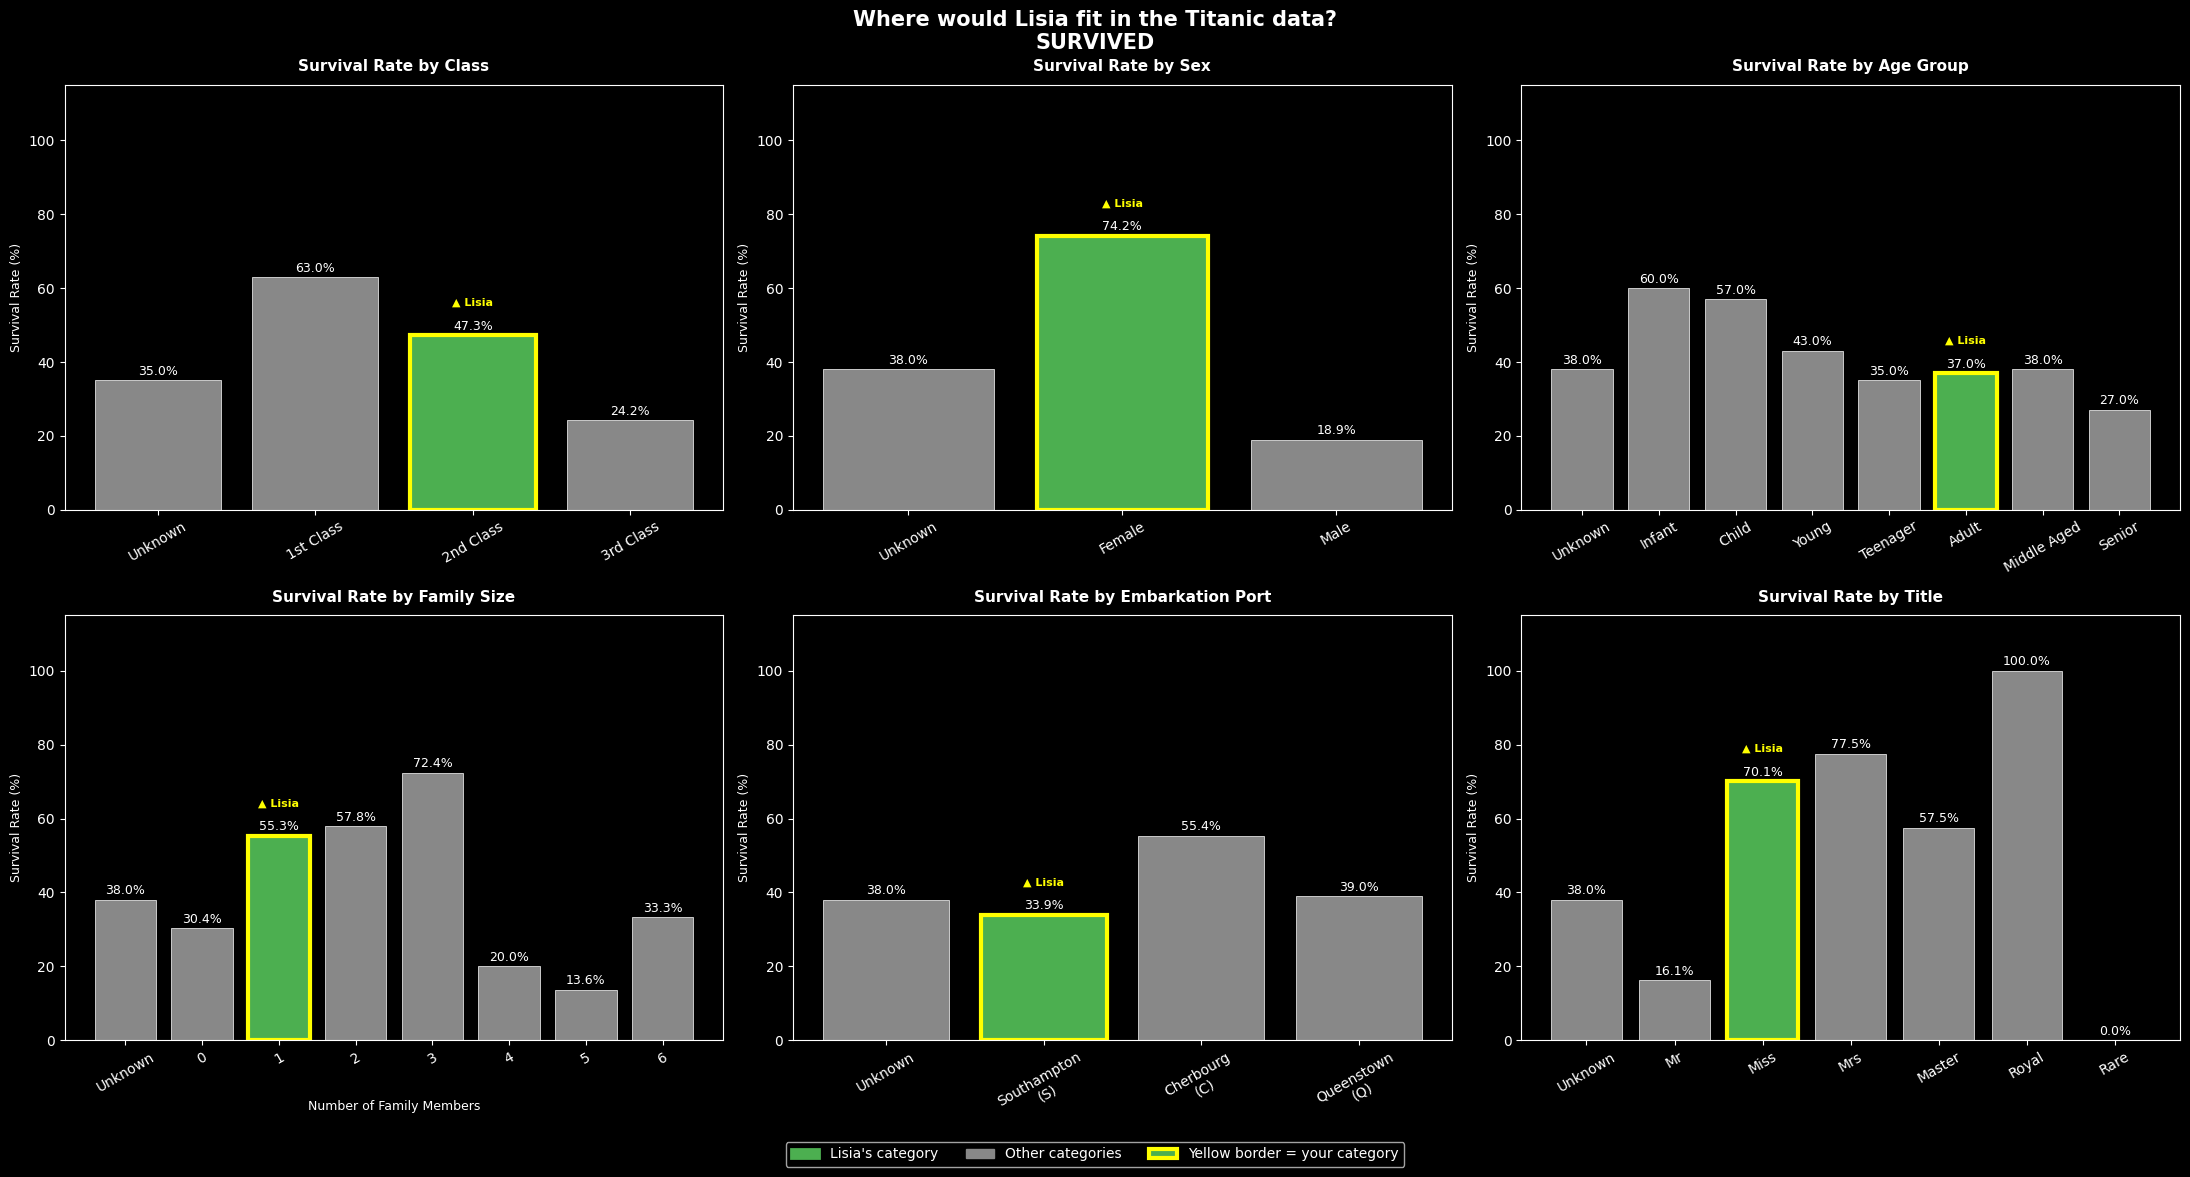

In [ ]:
# interactive and visualization with better data intergration want to update files to reflect real tim edata
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def predict_survival_friendly():
    print("=== IT Club prediction ===\n")

    # name
    name = input("Name: ")

    print("\nSex:")
    print("male: m | female: f")
    sex_input = input("Sex: ").lower()
    if sex_input == "m":
        sex = 0
        sex_label = "Male"
    elif sex_input == "f":
        sex = 1
        sex_label = "Female"
    # age group (maybe will drop for age??) (need to clean up and choose between age or just age group)
    age = input("Age: ").strip()
    age = int(age)
    if age >= 0 and age <= 4:
      age_group = 1
    elif age > 4 and age <= 12:
      age_group = 2
    elif age > 12 and age <= 15:
      age_group = 3
    elif age > 15 and age <= 19:
      age_group = 4
    elif age > 19 and age <= 39:
      age_group = 5
    elif age > 39 and age <= 49:
      age_group = 6
    elif age > 49:
      age_group = 7

    # class
    print("\nClass:")
    print("1 = First Class | 2 = Second Class | 3 = Third Class | 0 = Unknown")
    pclass = int(input("Class: "))

    # title using the first titles that replaced earlier
    print("\nTitle:")
    print("1 = Mr | 2 = Ms | 3 = Mrs | 4 = None | 5 = VIP | 6 = Rare | 0 = Professional")
    title = int(input("Title: "))

    # family
    print("\nFamily Information:")
    print("Enter 0 if unknown or none")
    sibsp = int(input("Number of Siblings/Spouses aboard: "))
    parch = int(input("Number of Parents/Children aboard: "))
    family_size = sibsp + parch

    # fare from class (not important) (taking the average of fares)
    fare_map = {0: 15, 1: 100, 2: 30, 3: 10}
    fare = fare_map.get(pclass, 15)


    # memeber data (embark will default to 1 as its unimportant)
    passenger = pd.DataFrame({
        'Pclass': [pclass if pclass != 0 else 3],
        'Sex': [sex],
        'Age': [age_group],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Embarked': [1],
        'Title': [title if title != 0 else 1]
    })

    # using randomforest to take in the new data compared to the CSV files
    result = randomforest.predict(passenger)
    outcome = "SURVIVED" if result[0] == 1 else "DIED"

    print(f"\n{name} would have... {outcome}")

    # charts
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f"Where would {name} fit in the Titanic data?\n{outcome}",
                 fontsize=15, fontweight='bold')

    ax = axes.flatten()

    def draw_bars(axis, labels, values, highlight_idx, title, xlabel=None):
        colors = ['#4CAF50' if i == highlight_idx else '#888888'
                  for i in range(len(values))]
        bars = axis.bar(labels, values, color=colors,
                       edgecolor='white', linewidth=0.5)

        # highlight the new user data replacing arrow
        bars[highlight_idx].set_edgecolor('yellow')
        bars[highlight_idx].set_linewidth(3)

        # percentage
        for bar, val in zip(bars, values):
            axis.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1.5,
                     f'{val:.1f}%', ha='center', fontsize=9,
                     color='white')

        axis.set_title(title, fontsize=11, fontweight='bold', pad=10)
        axis.set_ylabel('Survival Rate (%)', fontsize=9)
        axis.set_ylim(0, 115)
        if xlabel:
            axis.set_xlabel(xlabel, fontsize=9)
        axis.tick_params(axis='x', rotation=30)

        # shows the new userdata in the charts as highlighted
        axis.text(highlight_idx,
                 values[highlight_idx] + 8,
                 f'▲ {name}',
                 ha='center', fontsize=8,
                 color='yellow', fontweight='bold')

    # chart 1 by class
    class_survival = train.groupby('Pclass')['Survived'].mean() * 100
    class_labels = ['Unknown', '1st Class', '2nd Class', '3rd Class']
    class_values = [35.0,
                    class_survival.get(1, 0),
                    class_survival.get(2, 0),
                    class_survival.get(3, 0)]
    draw_bars(ax[0], class_labels, class_values, pclass,
              'Survival Rate by Class')

    # chart 2 by sex
    sex_labels = ['Unknown', 'Female', 'Male']
    sex_values = [38.0,
                  train[train['Sex'] == 1]['Survived'].mean() * 100,
                  train[train['Sex'] == 0]['Survived'].mean() * 100]
    user_sex_idx = user_sex_idx = 2 if sex == 0 else 1
    draw_bars(ax[1], sex_labels, sex_values, user_sex_idx,
              'Survival Rate by Sex')

    # chart 3 by age group
    age_labels = ['Unknown', 'Infant', 'Child', 'Young',
                        'Teenager', 'Adult', 'Middle Aged', 'Senior']
    age_values = [38.0, 60, 57, 43, 35, 37, 38, 27]
    user_age_idx = age_group
    draw_bars(ax[2], age_labels, age_values, user_age_idx,
              'Survival Rate by Age Group')

    # chart 6 by family
    train['FamilySize'] = train['SibSp'] + train['Parch']
    family_survival = train.groupby('FamilySize')['Survived'].mean() * 100
    family_sizes = [fs for fs in sorted(train['FamilySize'].unique()) if fs <= 6]
    family_labels = ['Unknown'] + [str(fs) for fs in family_sizes]
    family_values = [38.0] + [family_survival.get(fs, 0)
                               for fs in family_sizes]
    user_family_size = min(family_size, 6)
    user_family_idx = (family_sizes.index(user_family_size) + 1
                       if user_family_size in family_sizes else 0)
    draw_bars(ax[3], family_labels, family_values, user_family_idx,
              'Survival Rate by Family Size',
              xlabel='Number of Family Members')

    # chart 5 by embark
    port_survival = train.groupby('Embarked')['Survived'].mean() * 100
    port_labels = ['Unknown', 'Southampton\n(S)',
                   'Cherbourg\n(C)', 'Queenstown\n(Q)']
    port_values = [38.0,
                   port_survival.get(1, 0),
                   port_survival.get(2, 0),
                   port_survival.get(3, 0)]
    draw_bars(ax[4], port_labels, port_values, 1,
              'Survival Rate by Embarkation Port')

    # chart 6 by title
    title_survival = train.groupby('Title')['Survived'].mean() * 100
    title_names = ['Unknown', 'Mr', 'Miss', 'Mrs',
                   'Master', 'Royal', 'Rare']
    title_values = [38.0] + [title_survival.get(i+1, 0)
                              for i in range(6)]
    draw_bars(ax[5], title_names, title_values, title,
              'Survival Rate by Title')

    # legend
    user_patch = mpatches.Patch(color='#4CAF50',
                                label=f'{name}\'s category',
                                linewidth=2)
    other_patch = mpatches.Patch(color='#888888',
                                 label='Other categories')
    you_patch = mpatches.Patch(facecolor='#4CAF50',
                                edgecolor='yellow',
                                linewidth=3,
                                label='Yellow border = your category')
    fig.legend(handles=[user_patch, other_patch, you_patch],
               loc='lower center', ncol=3, fontsize=10,
               bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

predict_survival_friendly()

# export model